# EDA 01 — How does uncertainty scale with geography size?

**Question (README, Phase 1 Step 5):** How does the reliability of ACS estimates change as we zoom from county to tract to block group?

**Plain-English setup.** Every ACS number is an estimate from a sample, so it ships with a margin of error (MOE). To compare reliability across places and variables we use the **coefficient of variation (CV)** — the noise expressed as a fraction of the estimate itself. A CV of 0.30 means the noise is 30% the size of the thing being measured. Formula, following the ACS "Accuracy of the Data" documentation:

$$CV = \frac{MOE / 1.645}{estimate}$$

ACS MOEs are published at 90% confidence; dividing by 1.645 converts an MOE to a standard error. All terms are defined in [`docs/glossary.md`](../docs/glossary.md).

**Data.** ACS 5-year vintage 2024 (2020–2024), New Jersey, county / tract / block group, pulled by [`ingestion/pull_acs_nj.py`](../ingestion/pull_acs_nj.py). Raw files are local-only and regenerable: `python ingestion/pull_acs_nj.py`. Shared formulas live in [`analysis/acs.py`](../analysis/acs.py).

**Expectation going in:** CV should explode as geographies shrink — the project's central empirical fact. This notebook produces the first mentor-meeting chart.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Notebook lives in /notebooks; the analysis package lives at the repo root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import acs

levels = {lvl: acs.load_level(lvl) for lvl in acs.LEVELS}

# Row counts hard-checked at ingestion; re-assert so a stale/partial file fails loudly.
EXPECTED_ROWS = {"county": 21, "tract": 2181, "block_group": 6599}
for lvl, df in levels.items():
    assert len(df) == EXPECTED_ROWS[lvl], f"{lvl}: {len(df)} rows, expected {EXPECTED_ROWS[lvl]}"
print("Loaded:", {lvl: len(df) for lvl, df in levels.items()})

Loaded: {'county': 21, 'tract': 2181, 'block_group': 6599}


## 1. Data quality before analysis

House rule: sanity-check every dataset before analyzing it. Known landmines from ingestion (see [`HANDOFF.md`](../HANDOFF.md)): ACS annotation codes arrive as blanks with their meanings erased, median income is top-coded at \$250,001, and poverty/subgroup tables are not published below tract level.

In [2]:
dq_rows = []
for lvl, df in levels.items():
    for code, name in acs.VARIABLES.items():
        e, m = df[f"{code}E"], df[f"{code}M"]
        dq_rows.append({
            "level": lvl,
            "variable": name,
            "n": len(df),
            "estimate missing": int(e.isna().sum()),
            "MOE missing": int(m.isna().sum()),
            "estimate = 0": int((e == 0).sum()),
            "top-coded": int((e == acs.INCOME_TOP_CODE).sum()) if code == "B19013_001" else 0,
        })
pd.DataFrame(dq_rows)

,level,variable,n,estimate missing,MOE missing,estimate = 0,top-coded
0,county,Total population,21,0,21,0,0
1,county,Median household income,21,0,0,0,0
2,county,People below poverty level,21,0,0,0,0
3,county,Black male 65-74,21,0,0,0,0
4,county,Black male 75-84,21,0,0,0,0
5,county,Black male 85+,21,0,0,3,0
6,county,Black female 65-74,21,0,0,0,0
7,county,Black female 75-84,21,0,0,0,0
8,county,Black female 85+,21,0,0,1,0
9,tract,Total population,2181,0,0,9,0


In [3]:
# Oddballs: income estimate present (and not top-coded) but MOE missing.
bg = levels["block_group"]
odd = bg[bg["B19013_001E"].notna() & bg["B19013_001M"].isna() & ~acs.flag_topcoded_income(bg)]
odd[["NAME", "B19013_001E", "B19013_001M"]]

,NAME,B19013_001E,B19013_001M
1327,Block Group 1; Census Tract 6015; Camden Count...,2499.0,NaN
2887,Block Group 2; Census Tract 54; Hudson County;...,2499.0,NaN


### What the table says

- **County total-population MOE is missing for all 21 counties — and that is *good* news, not missing data.** County population is a *controlled estimate* (pinned to official Population Estimates Program benchmarks), so no sampling MOE is published; the blank arrives via the `-555555555` annotation code. This is the poster child for why a missing MOE must never be naively read as "unknown reliability" — here it means *extremely reliable*.
- **Poverty and the Black 65+ subgroup cells are 100% empty at block group** — those tables aren't published below tract (confirmed at ingestion; mentor question logged in the README). Block-group comparisons below therefore use total population and median income only.
- **Top-coded income:** 41 tracts and 270 block groups sit at exactly \$250,001 ("somewhere above \$250k"). Every top-coded estimate also has a missing MOE — the Bureau publishes no MOE for a censored median. These rows are flagged and excluded from the CV distributions below.
- **Two block groups have a real (non-top-coded) income estimate but no MOE** (shown above) — consistent with some other annotation whose code censusdis erased. Two rows out of 6,599 move nothing; noted for the future data dictionary.
- **Zero-population geographies exist:** 9 tracts and 71 block groups (parks, airports, industrial zones). CV is undefined there.
- **The subgroup cells are mostly zeros at tract level** (50–89% of tracts per cell). A zero count has no CV, so single-cell reliability analysis at tract level describes only the minority of tracts where the cell is nonzero — one more reason notebook 02 will aggregate the six cells into one 65+ estimate.

## 2. Computing CVs

Choices (per the approved EDA plan; formulas and citations live in [`analysis/acs.py`](../analysis/acs.py)):

- **Zero or missing estimates → CV is NaN.** Division by zero is meaningless — a zero count is not "infinitely unreliable."
- **Top-coded incomes are excluded** from income CV distributions (censored, not measured; counts reported above).
- **Missing MOEs → CV is NaN**, with the controlled-estimate caveat above.
- Reference lines mark **CV = 0.12 / 0.30 / 0.40** for orientation: ESRI's widely-used ACS reliability convention labels CV < 0.12 *high reliability* and CV > 0.40 *low*; the National Center for Health Statistics flags estimates with CV > 0.30 as unreliable ("NCHS Data Presentation Standards"). **These are shown descriptively only** — this project's own reliability tiers are a deliberate later decision (weeks 4–6, with mentors).

In [4]:
long = pd.concat(
    [acs.cv_long(df, list(acs.VARIABLES), lvl) for lvl, df in levels.items()],
    ignore_index=True,
)
long["level"] = pd.Categorical(long["level"], categories=acs.LEVELS, ordered=True)
long["variable"] = pd.Categorical(
    long["variable"], categories=list(acs.VARIABLES.values()), ordered=True
)

# Top-coded income is censored, not measured -- its CV is not comparable.
long = long[~((long["code"] == "B19013_001") & (long["estimate"] == acs.INCOME_TOP_CODE))]

summary = (
    long.dropna(subset=["cv"])
    .groupby(["variable", "level"], observed=True)["cv"]
    .agg(
        n="size",
        median_cv="median",
        pct_above_030=lambda c: 100 * (c > 0.30).mean(),
        pct_above_040=lambda c: 100 * (c > 0.40).mean(),
    )
    .round({"median_cv": 3, "pct_above_030": 1, "pct_above_040": 1})
)
summary

n  median_cv  pct_above_030  \
variable                   level                                         
Total population           tract        2172      0.079            0.2   
                           block_group  6528      0.192           11.7   
Median household income    county         21      0.014            0.0   
                           tract        2109      0.128            5.0   
                           block_group  5785      0.204           27.0   
People below poverty level county         21      0.046            0.0   
                           tract        2161      0.383           80.1   
Black male 65-74           county         21      0.040           14.3   
                           tract        1088      0.851           98.9   
Black male 75-84           county         21      0.098           19.0   
                           tract         622      0.914           99.7   
Black male 85+             county         18      0.276           44.4   
                           tract         244      0.977          100.0   
Black female 65-74         county         21      0.027            4.8   
                           tract        1101      0.741           96.7   
Black female 75-84         county         21      0.090            9.5   
                           tract         842      0.889           99.2   
Black female 85+           county         20      0.219           35.0   
                           tract         514      0.950           99.8   

                                        pct_above_040  
variable                   level                       
Total population           tract                  0.2  
                           block_group            2.8  
Median household income    county                 0.0  
                           tract                  1.6  
                           block_group           12.5  
People below poverty level county                 0.0  
                           tract                 44.4  
Black male 65-74           county                 0.0  
                           tract                 93.4  
Black male 75-84           county                19.0  
                           tract                 97.6  
Black male 85+             county                27.8  
                           tract                 98.8  
Black female 65-74         county                 0.0  
                           tract                 89.0  
Black female 75-84         county                 9.5  
                           tract                 94.9  
Black female 85+           county                15.0  
                           tract                 99.4

### Reading the table

Median CV for **median household income**: **0.014 at county → 0.128 at tract → 0.204 at block group** — a 14× degradation from county to block group for the *same statistic from the same survey*. At block group, **27% of income estimates cross the NCHS caution line** (CV > 0.30).

Two findings beyond the headline:

- **Poverty is already unreliable at tract level:** median CV 0.38, with **80% of tracts above CV 0.30** — and this is a policy-critical variable routinely quoted at tract level.
- **Small subgroup counts are effectively noise at tract level:** median CVs 0.74–0.98, with 97–100% of nonzero tracts above CV 0.30. Sampling error dominates these cells completely.

## 3. The headline chart

One statistic (median household income), three zoom levels. The y-axis is logarithmic — the county and block-group distributions would not fit on the same linear axis, which is itself the finding.

Chart saved to data\processed\eda01_income_cv_by_geography.png (local-only, regenerable)


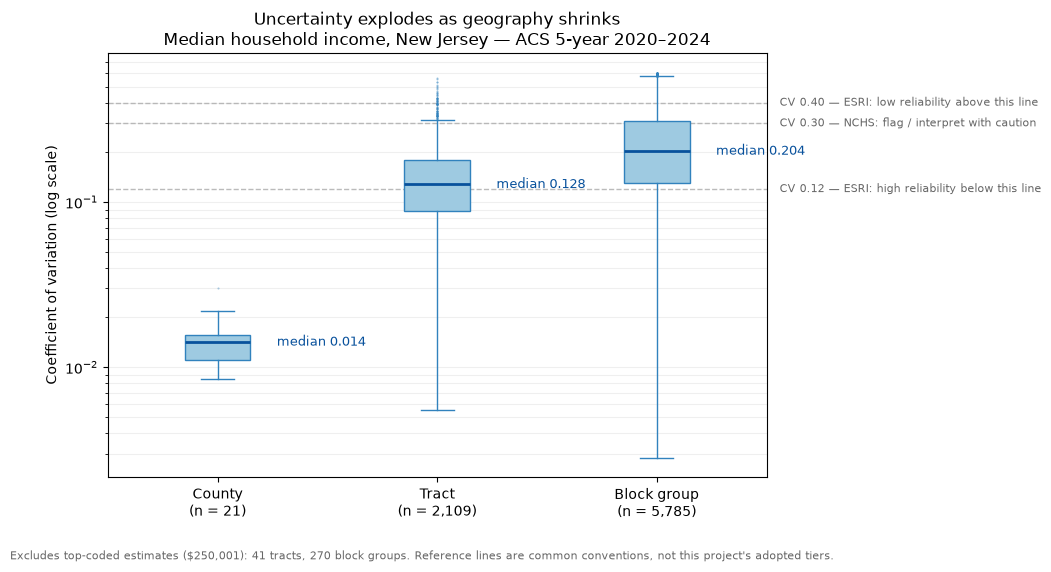

In [5]:
inc = long[(long["code"] == "B19013_001") & long["cv"].notna()]
pretty = {"county": "County", "tract": "Tract", "block_group": "Block group"}
data = [inc.loc[inc["level"] == lvl, "cv"].to_numpy() for lvl in acs.LEVELS]
tick_labels = [f"{pretty[lvl]}\n(n = {len(d):,})" for lvl, d in zip(acs.LEVELS, data)]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.boxplot(
    data,
    tick_labels=tick_labels,
    patch_artist=True,
    boxprops=dict(facecolor="#9ecae1", edgecolor="#3182bd"),
    medianprops=dict(color="#08519c", linewidth=2),
    whiskerprops=dict(color="#3182bd"),
    capprops=dict(color="#3182bd"),
    flierprops=dict(marker=".", markersize=3, markerfacecolor="#3182bd",
                    markeredgecolor="none", alpha=0.4),
)
ax.set_yscale("log")
ax.set_axisbelow(True)
ax.grid(axis="y", which="both", alpha=0.2)

for y, label in [
    (0.12, "CV 0.12 — ESRI: high reliability below this line"),
    (0.30, "CV 0.30 — NCHS: flag / interpret with caution"),
    (0.40, "CV 0.40 — ESRI: low reliability above this line"),
]:
    ax.axhline(y, color="#bbbbbb", linestyle="--", linewidth=1, zorder=0)
    ax.text(1.02, y, label, transform=ax.get_yaxis_transform(),
            fontsize=8, va="center", color="#666666")

for i, d in enumerate(data, start=1):
    med = float(pd.Series(d).median())
    ax.text(i + 0.27, med, f"median {med:.3f}", fontsize=9,
            va="center", color="#08519c")

ax.set_ylabel("Coefficient of variation (log scale)")
ax.set_title(
    "Uncertainty explodes as geography shrinks\n"
    "Median household income, New Jersey — ACS 5-year 2020–2024",
    fontsize=12,
)
fig.text(
    0.01, -0.04,
    r"Excludes top-coded estimates (\$250,001): 41 tracts, 270 block groups. "
    "Reference lines are common conventions, not this project's adopted tiers.",
    fontsize=8, color="#666666",
)

out = REPO_ROOT / "data" / "processed" / "eda01_income_cv_by_geography.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

In [6]:
# Guard the central claim: median income CV must strictly increase as geography shrinks.
med = inc.groupby("level", observed=True)["cv"].median()
assert med["county"] < med["tract"] < med["block_group"], med.to_dict()

worst_moe = {lvl: levels[lvl]["B19013_001M"].max() for lvl in acs.LEVELS}
print("Median income CV by level:", {k: round(v, 3) for k, v in med.items()})
print("Worst income MOE by level:", {k: f"+/-${v:,.0f}" for k, v in worst_moe.items()})

Median income CV by level: {'county': 0.014, 'tract': 0.128, 'block_group': 0.204}
Worst income MOE by level: {'county': '+/-$3,982', 'tract': '+/-$101,707', 'block_group': '+/-$247,531'}


## 4. Findings

**What did we find?** The central empirical fact holds, dramatically. For the same statistic (median household income), the typical CV grows 14× from county (0.014) to block group (0.204), and the worst-case MOE grows from ±\$3,982 to ±\$247,531 — a block group whose uncertainty band is wider than the entire income scale. Beyond the headline: tract-level **poverty** — a variable planners actually use at tract level — is above the CV 0.30 caution line in **80% of NJ tracts**, and small subgroup counts (Black 65+ single cells) are essentially noise at tract level (median CV ≈ 0.9). We also confirmed two "silent" reliability states that carry no MOE at all: controlled estimates (extremely reliable) and top-coded medians (censored) — opposite meanings, identical blanks.

**Why does it matter to the Census Bureau?** Nothing on data.census.gov tells a non-technical user any of this at a glance. A county planner quoting a tract poverty rate has an 80% chance of quoting a low-reliability number without knowing it. This is precisely the gap the composite reliability score and dashboard are meant to close (Q2, Q4) — and the fact that reliability depends jointly on geography level *and* variable type means a single blanket warning ("small areas are noisy") is not enough.

**What next?**
- **EDA 02 — CV by variable type:** isolate the mechanism (small counts → big relative noise) at tract level, and build the documented root-sum-of-squares 65+ aggregate.
- **EDA 03 — tract choropleth:** show *where* unreliability concentrates; crude prototype of the dashboard view.
- This notebook's chart is the current candidate for the July 22 mentor slide.